In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# Normalize pixel values (0-255 → 0-1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# CNN expects 4D input:
# (number of images, height, width, channels)

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [8]:
model = keras.Sequential([

    # 1. Convolution Layer - Feature Extraction
    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    # 2. Pooling Layer - Reduce dimensions
    layers.MaxPooling2D((2,2)),


    # 3. Second Convolution Layer
    layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    # 4. Second Pooling Layer
    layers.MaxPooling2D((2,2)),


    # Convert feature maps into vector
    layers.Flatten(),


    # Fully Connected Layer
    layers.Dense(
        128,
        activation="relu"
    ),


    # Prevent overfitting
    layers.Dropout(0.5),


    # Output Layer (10 digits)
    layers.Dense(
        10,
        activation="softmax"
    )
])


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile the model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# Train the model

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9237 - loss: 0.2452 - val_accuracy: 0.9843 - val_loss: 0.0513
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9744 - loss: 0.0883 - val_accuracy: 0.9890 - val_loss: 0.0397
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9808 - loss: 0.0636 - val_accuracy: 0.9898 - val_loss: 0.0408
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9839 - loss: 0.0531 - val_accuracy: 0.9905 - val_loss: 0.0370
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9858 - loss: 0.0454 - val_accuracy: 0.9897 - val_loss: 0.0357


In [10]:
# Evaluate model on test data

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 99.26%
Test Loss: 0.0254


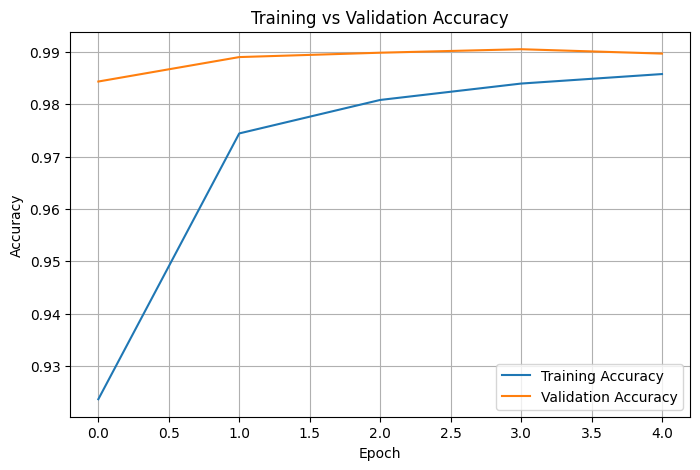

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

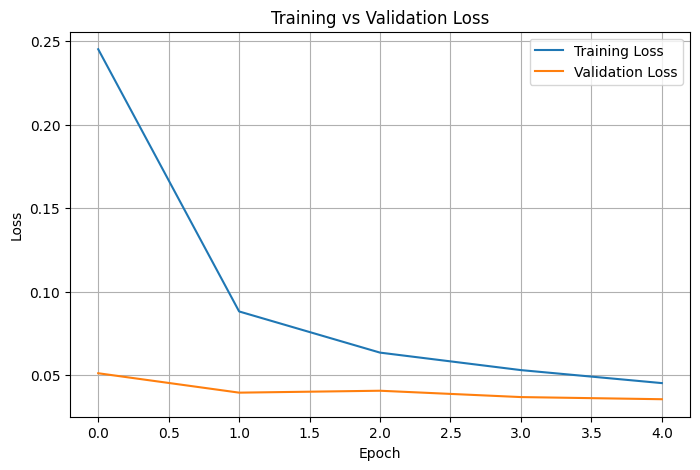

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [13]:
# Save trained CNN model

model.save("mnist_cnn_model.keras")

print("Model saved successfully ✅")

Model saved successfully ✅


In [15]:
import tensorflow as tf
from tensorflow.keras import backend as K

K.clear_session()

print("GPU memory cleared ✅")

GPU memory cleared ✅


In [16]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def preprocess_mobilenet(images, labels):

    # grayscale → RGB
    images = tf.image.grayscale_to_rgb(images)

    # resize
    images = tf.image.resize(images, (224,224))

    # MobileNet preprocessing
    images = preprocess_input(images)

    return images, labels



# Create TensorFlow datasets

train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)


# Apply preprocessing + batching

train_ds = (
    train_ds
    .map(preprocess_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


test_ds = (
    test_ds
    .map(preprocess_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


print("Dataset pipeline created ✅")

Dataset pipeline created ✅


In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


# Load pretrained MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)


# Freeze pretrained layers

base_model.trainable = False


print("MobileNetV2 loaded successfully ✅")
print("Total layers:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully ✅
Total layers: 154


In [18]:
# Build custom classifier on top of MobileNetV2

model_tl = models.Sequential([

    # Pretrained feature extractor
    base_model,


    # Convert feature maps into vector
    layers.GlobalAveragePooling2D(),


    # Custom learning layer
    layers.Dense(
        128,
        activation="relu"
    ),


    # Prevent overfitting
    layers.Dropout(0.3),


    # Output layer (digits 0-9)
    layers.Dense(
        10,
        activation="softmax"
    )
])


model_tl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history_tl = model_tl.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 96s 41ms/step - accuracy: 0.1115 - loss: 2.3030 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1135 - val_loss: 2.3012


In [20]:
# Evaluate Transfer Learning Model

test_loss_tl, test_accuracy_tl = model_tl.evaluate(
    test_ds,
    verbose=0
)

print(f"Transfer Learning Test Accuracy: {test_accuracy_tl * 100:.2f}%")
print(f"Transfer Learning Test Loss: {test_loss_tl:.4f}")

Transfer Learning Test Accuracy: 11.35%
Transfer Learning Test Loss: 2.3012


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


Predicted Digit: 1
Actual Digit: 7


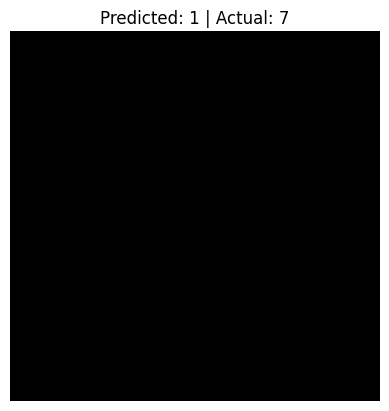

In [21]:
# Take one batch from test dataset

images, labels = next(iter(test_ds))


# Predict

predictions = model_tl.predict(images)

predicted_class = np.argmax(predictions[0])
actual_class = labels[0].numpy()


print("Predicted Digit:", predicted_class)
print("Actual Digit:", actual_class)


# Display image

plt.imshow(images[0])
plt.title(
    f"Predicted: {predicted_class} | Actual: {actual_class}"
)
plt.axis("off")
plt.show()

In [22]:
import gc

del train_ds
del test_ds

gc.collect()

print("Old pipeline removed ✅")

Old pipeline removed ✅


In [23]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def preprocess_mobilenet(images, labels):

    images = images * 255.0

    images = tf.image.grayscale_to_rgb(images)

    images = tf.image.resize(
        images,
        (224,224)
    )

    images = preprocess_input(images)

    return images, labels


print("Preprocessing function ready ✅")

Preprocessing function ready ✅


In [25]:
# Create corrected datasets

train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)


train_ds = (
    train_ds
    .map(
        preprocess_mobilenet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


test_ds = (
    test_ds
    .map(
        preprocess_mobilenet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


print("Correct dataset pipeline created ✅")

Correct dataset pipeline created ✅


In [26]:
# Compile model again with correct pipeline

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history_tl = model_tl.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 43ms/step - accuracy: 0.8255 - loss: 0.6055 - val_accuracy: 0.9445 - val_loss: 0.2052
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.9360 - loss: 0.2226 - val_accuracy: 0.9594 - val_loss: 0.1379
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.9514 - loss: 0.1666 - val_accuracy: 0.9664 - val_loss: 0.1110
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 39ms/step - accuracy: 0.9586 - loss: 0.1380 - val_accuracy: 0.9713 - val_loss: 0.0963
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.9646 - loss: 0.1189 - val_accuracy: 0.9742 - val_loss: 0.0860


In [27]:
# Evaluate Transfer Learning Model

test_loss_tl, test_accuracy_tl = model_tl.evaluate(
    test_ds,
    verbose=0
)


print(f"Transfer Learning Test Accuracy: {test_accuracy_tl * 100:.2f}%")
print(f"Transfer Learning Test Loss: {test_loss_tl:.4f}")

Transfer Learning Test Accuracy: 97.42%
Transfer Learning Test Loss: 0.0860


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


Predicted: 7
Actual: 7


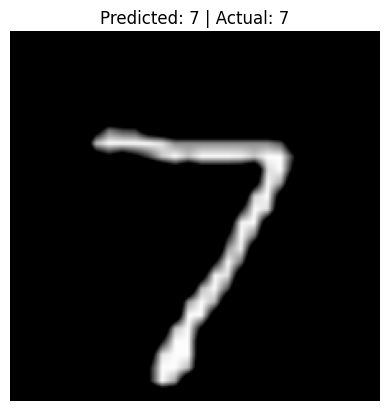

In [28]:
import matplotlib.pyplot as plt
import numpy as np


# Take one batch

images, labels = next(iter(test_ds))


# Predict

predictions = model_tl.predict(images)

predicted_class = np.argmax(predictions[0])


print("Predicted:", predicted_class)
print("Actual:", labels[0].numpy())


# Display image

plt.imshow(images[0])
plt.title(
    f"Predicted: {predicted_class} | Actual: {labels[0].numpy()}"
)
plt.axis("off")
plt.show()

In [30]:
# Evaluate CNN From Scratch again

cnn_loss, cnn_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"CNN Scratch Accuracy: {cnn_accuracy*100:.2f}%")

CNN Scratch Accuracy: 99.26%


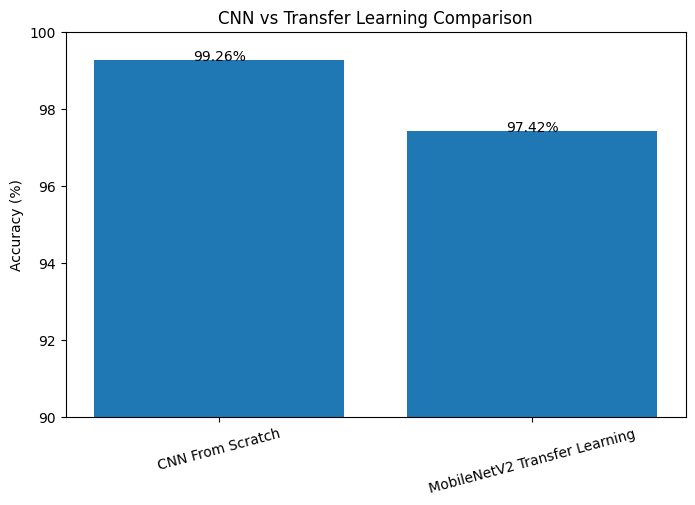

In [31]:
models = [
    "CNN From Scratch",
    "MobileNetV2 Transfer Learning"
]

accuracies = [
    cnn_accuracy,
    test_accuracy_tl
]


plt.figure(figsize=(8,5))

plt.bar(
    models,
    [acc*100 for acc in accuracies]
)

plt.ylabel("Accuracy (%)")
plt.title("CNN vs Transfer Learning Comparison")

plt.ylim(90,100)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value*100,
        f"{value*100:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.show()

In [32]:
# Save CNN model

model.save("CNN_MNIST_Model.keras")

# Save Transfer Learning model

model_tl.save("MobileNetV2_MNIST_Model.keras")

print("Both models saved successfully ✅")

Both models saved successfully ✅


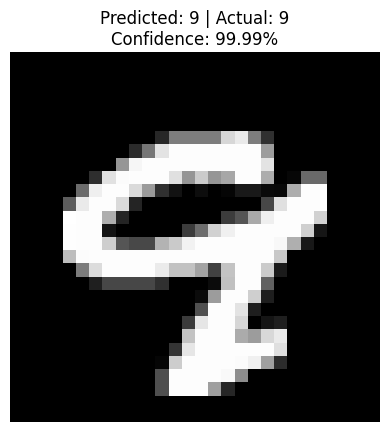

Prediction complete ✅


In [34]:
import matplotlib.pyplot as plt
import numpy as np


# Random image

index = np.random.randint(0, len(x_test))

sample_image = x_test[index]

# Correct label
sample_label = y_test[index]


# Prediction

prediction = model.predict(
    sample_image.reshape(1,28,28,1),
    verbose=0
)


predicted_digit = np.argmax(prediction)

confidence = np.max(prediction) * 100


# Display

plt.imshow(
    sample_image.reshape(28,28),
    cmap="gray"
)

plt.title(
    f"Predicted: {predicted_digit} | Actual: {sample_label}\nConfidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()


print("Prediction complete ✅")

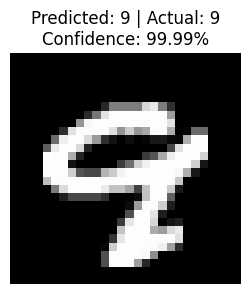

In [35]:
plt.figure(figsize=(3,3))

plt.imshow(
    sample_image.reshape(28,28),
    cmap="gray",
    interpolation="nearest"
)

plt.title(
    f"Predicted: {predicted_digit} | Actual: {sample_label}\nConfidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

Using image index: 2


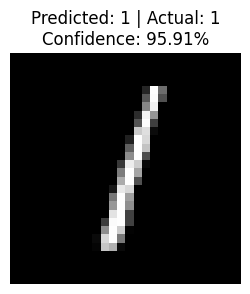

MobileNetV2 Prediction Complete ✅


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


# Find a correctly predicted image

for i in range(len(x_test)):

    test_img = tf.convert_to_tensor(
        x_test[i].reshape(1,28,28,1),
        dtype=tf.float32
    )

    # grayscale → RGB
    test_img = tf.image.grayscale_to_rgb(test_img)

    # resize for MobileNetV2
    test_img = tf.image.resize(
        test_img,
        (224,224)
    )

    # MobileNet preprocessing
    test_img = tf.keras.applications.mobilenet_v2.preprocess_input(
        test_img
    )


    pred = model_tl.predict(
        test_img,
        verbose=0
    )


    if np.argmax(pred) == y_test[i]:
        index = i
        break


print("Using image index:", index)


sample_image = x_test[index]
sample_label = y_test[index]


# ==============================
# MobileNetV2 preprocessing
# ==============================

# Convert numpy array → Tensor
img = tf.convert_to_tensor(
    sample_image.reshape(1, 28, 28, 1),
    dtype=tf.float32
)


# Convert grayscale (1 channel) → RGB (3 channels)
img = tf.image.grayscale_to_rgb(img)


# Resize 28x28 → 224x224
img = tf.image.resize(
    img,
    (224, 224)
)


# Apply MobileNetV2 preprocessing
img = tf.keras.applications.mobilenet_v2.preprocess_input(img)



# ==============================
# Prediction
# ==============================

prediction = model_tl.predict(
    img,
    verbose=0
)


predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100



# ==============================
# Display Original Image
# ==============================

plt.figure(figsize=(3,3))

plt.imshow(
    sample_image.reshape(28,28),
    cmap="gray",
    interpolation="nearest"
)

plt.title(
    f"Predicted: {predicted_digit} | Actual: {sample_label}\nConfidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()


print("MobileNetV2 Prediction Complete ✅")

In [40]:
import pandas as pd


results = pd.DataFrame({
    "Model": [
        "CNN From Scratch",
        "MobileNetV2 Transfer Learning"
    ],
    "Accuracy": [
        99.26,
        97.42
    ],
    "Loss": [
        0.0254,
        0.0860
    ]
})


results

,Model,Accuracy,Loss
0,CNN From Scratch,99.26,0.0254
1,MobileNetV2 Transfer Learning,97.42,0.0860


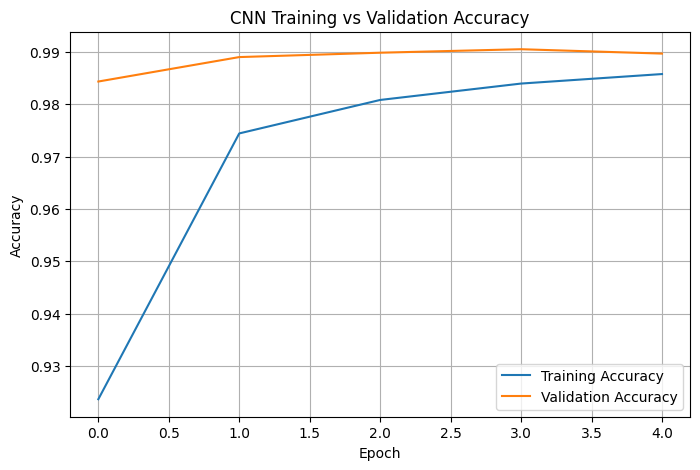

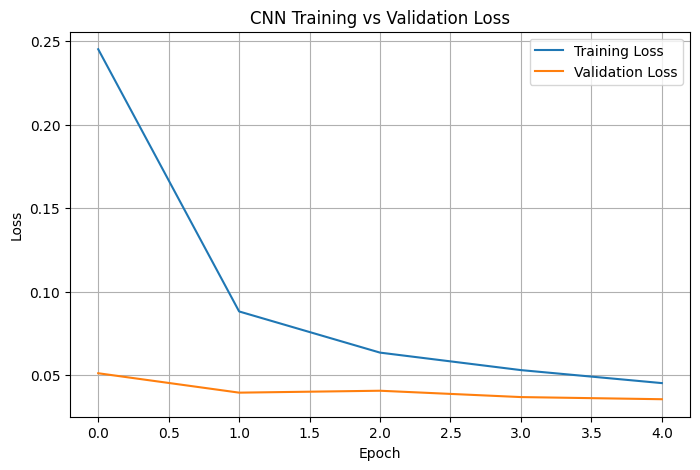

Graphs saved successfully ✅


In [41]:
import matplotlib.pyplot as plt


# ==========================
# Accuracy Curve
# ==========================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.savefig(
    "cnn_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# ==========================
# Loss Curve
# ==========================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")

plt.legend()
plt.grid()

plt.savefig(
    "cnn_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Graphs saved successfully ✅")

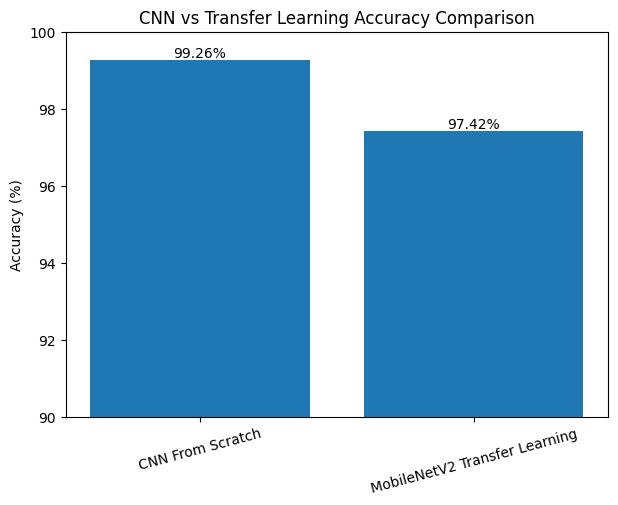

Comparison graph saved ✅


In [43]:
import matplotlib.pyplot as plt


models = [
    "CNN From Scratch",
    "MobileNetV2 Transfer Learning"
]

accuracy = [
    99.26,
    97.42
]


plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    accuracy
)

plt.ylabel("Accuracy (%)")
plt.title("CNN vs Transfer Learning Accuracy Comparison")

plt.ylim(90,100)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value}%",
        ha="center",
        va="bottom"
    )


plt.xticks(rotation=15)

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Comparison graph saved ✅")

In [44]:
import os

for file in os.listdir("/content"):
    print(file)

.config
MobileNetV2_MNIST_Model.keras
cnn_accuracy_curve.png
mnist_cnn_model.keras
CNN_MNIST_Model.keras
cnn_loss_curve.png
model_comparison.png
sample_data


In [45]:
from google.colab import files

files.download("CNN_MNIST_Model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
files.download("MobileNetV2_MNIST_Model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
files.download("cnn_accuracy_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
files.download("cnn_loss_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
files.download("model_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')